In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WEEK1.csv', header=1)

In [3]:
df.head()

,Week,Address,Number of delivered orders,Basket size,Bad rated orders due to wrong or Missing Products,Bad rated orders due to store packaging Issues,Bad rated orders due to store allergy not considered,Bad rated orders due to to Poor Quality,Cancelled Orders Due to Customer Absent,Cancelled Orders due to Partner Printer/internet issue,Cancelled Orders Due to Partner Products Not Available,Cancelled Orders Due to Partner Store Closed,Cancelled Orders Due to Store Cant Deliver,Refunds to customer
0,2025-01-04,"Av. de Monforte de Lemos, 12, Madrid, Spain",104,€21.65,1,0,0,1,0,0,0,0,0,€3.25
1,2025-02-01,"Av. de Monforte de Lemos, 12, Madrid, Spain",124,€20.95,1,0,0,0,0,0,0,0,0,€3.14
2,2025-02-08,"Av. de Monforte de Lemos, 12, Madrid, Spain",71,€22.94,1,0,0,0,0,0,0,0,0,€11.47
3,2025-02-15,"Av. de Monforte de Lemos, 12, Madrid, Spain",76,€21.11,1,0,0,0,0,0,0,0,0,€3.17
4,2025-03-08,"Av. de Monforte de Lemos, 12, Madrid, Spain",87,€22.43,1,0,0,1,0,0,0,0,0,€6.73


In [4]:
df.shape

(500, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   Week                                                    500 non-null    object
 1   Address                                                 500 non-null    object
 2   Number of delivered orders                              500 non-null    int64 
 3   Basket size                                             498 non-null    object
 4   Bad rated orders due to wrong or Missing Products       500 non-null    int64 
 5   Bad rated orders due to store packaging Issues          500 non-null    int64 
 6   Bad rated orders due to store allergy not considered    500 non-null    int64 
 7   Bad rated orders due to to  Poor Quality                500 non-null    int64 
 8   Cancelled Orders Due to Customer Absent           

In [6]:
df.isna().sum()

,0
Week,0
Address,0
Number of delivered orders,0
Basket size,2
Bad rated orders due to wrong or Missing Products,0
Bad rated orders due to store packaging Issues,0
Bad rated orders due to store allergy not considered,0
Bad rated orders due to to Poor Quality,0
Cancelled Orders Due to Customer Absent,0
Cancelled Orders due to Partner Printer/internet issue,0


In [7]:
df['Basket size']

,Basket size
0,€21.65
1,€20.95
2,€22.94
3,€21.11
4,€22.43
...,...
495,€17.87
496,€24.22
497,€24.02
498,€23.31


In [8]:
# Clean 'Basket size' column: remove '€' and convert to float
df['Basket size'] = df['Basket size'].astype(str).str.replace('€', '', regex=False)
df['Basket size'] = pd.to_numeric(df['Basket size'], errors='coerce')

# Fill NaN values in 'Basket size' with its median
df['Basket size'].fillna(df['Basket size'].median(), inplace=True)

/tmp/ipykernel_483/129152896.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Basket size'].fillna(df['Basket size'].median(), inplace=True)


In [9]:
df.isna().sum()

,0
Week,0
Address,0
Number of delivered orders,0
Basket size,0
Bad rated orders due to wrong or Missing Products,0
Bad rated orders due to store packaging Issues,0
Bad rated orders due to store allergy not considered,0
Bad rated orders due to to Poor Quality,0
Cancelled Orders Due to Customer Absent,0
Cancelled Orders due to Partner Printer/internet issue,0


Feature Enginnering


In [10]:
# A row showing the sum of cancelled orders due to different reasons as Cancelled Orders
df['Cancelled Orders'] = df['Cancelled Orders Due to Customer Absent'] + \
                        df['Cancelled Orders due to Partner Printer/internet issue'] + \
                        df['Cancelled Orders Due to Partner Products Not Available'] + \
                        df['Cancelled Orders Due to Partner Store Closed'] + \
                        df['Cancelled Orders Due to Store Cant Deliver']

display(df[['Cancelled Orders Due to Customer Absent', 'Cancelled Orders due to Partner Printer/internet issue', 'Cancelled Orders Due to Partner Products Not Available', 'Cancelled Orders Due to Partner Store Closed', 'Cancelled Orders Due to Store Cant Deliver', 'Cancelled Orders']].head())

,Cancelled Orders Due to Customer Absent,Cancelled Orders due to Partner Printer/internet issue,Cancelled Orders Due to Partner Products Not Available,Cancelled Orders Due to Partner Store Closed,Cancelled Orders Due to Store Cant Deliver,Cancelled Orders
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [11]:
display(df['Cancelled Orders'].head(30))

,Cancelled Orders
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [12]:
df['Cancelled Orders'].sum()

np.int64(197)

In [13]:
# Clean 'Refunds to customer' column: remove '€' and convert to float
df['Refunds to customer'] = df['Refunds to customer'].astype(str).str.replace('€', '', regex=False)
df['Refunds to customer'] = pd.to_numeric(df['Refunds to customer'], errors='coerce')

# Fill NaN values in 'Refunds to customer' with 0
df['Refunds to customer'].fillna(0, inplace=True)

# Now calculate the sum
df['Refunds to customer'].sum()

/tmp/ipykernel_483/3302809937.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Refunds to customer'].fillna(0, inplace=True)


np.float64(9282.24)

In [14]:
df.isna().sum()

,0
Week,0
Address,0
Number of delivered orders,0
Basket size,0
Bad rated orders due to wrong or Missing Products,0
Bad rated orders due to store packaging Issues,0
Bad rated orders due to store allergy not considered,0
Bad rated orders due to to Poor Quality,0
Cancelled Orders Due to Customer Absent,0
Cancelled Orders due to Partner Printer/internet issue,0


In [15]:
# A row showing the sum of Bad Rated orders due to different reasons as Bad Rated Totals
df['Bad Rated Total'] = df['Bad rated orders due to store allergy not considered']+ \
df['Bad rated orders due to wrong or Missing Products']+ \
df['Bad rated orders due to store packaging Issues'] + \
df['Bad rated orders due to to  Poor Quality']

df['Bad Rated Total']

,Bad Rated Total
0,2
1,1
2,1
3,1
4,2
...,...
495,0
496,0
497,1
498,0


In [16]:
# Total Number of Orders Delivered
df['Number of delivered orders'].sum()

np.int64(35284)

In [17]:
# Sum of delivered Orders Rated bad
sum_delivered_orders_bad_rated = df[df['Bad Rated Total'] > 0]['Number of delivered orders'].sum()
print(f"Sum of 'Number of delivered orders' for rows where 'Bad Rated Total' > 0: {sum_delivered_orders_bad_rated}")

Sum of 'Number of delivered orders' for rows where 'Bad Rated Total' > 0: 32330


In [18]:
df['Bad rated orders due to wrong or Missing Products'].sum()

np.int64(1394)

In [19]:
df['Bad rated orders due to store packaging Issues'].sum()

np.int64(41)

In [20]:
df['Bad rated orders due to to  Poor Quality'].sum()

np.int64(173)

In [21]:
df['Bad rated orders due to store allergy not considered'].sum()

np.int64(33)

In [22]:
# Calculating % of Good and Bad Orders
# Define 'good orders' (no bad ratings AND no cancellations)
good_orders_condition = (df['Bad Rated Total'] == 0) & (df['Cancelled Orders'] == 0)
good_orders_count = df[good_orders_condition].shape[0]

# Define 'bad orders' (the complement of good orders: at least one bad rating OR at least one cancellation)
bad_orders_condition = (df['Bad Rated Total'] > 0) | (df['Cancelled Orders'] > 0)
bad_orders_count = df[bad_orders_condition].shape[0]

total_rows = df.shape[0]

percentage_good_orders = (good_orders_count / total_rows) * 100
percentage_bad_orders = (bad_orders_count / total_rows) * 100

print(f"Total good orders (rows): {good_orders_count}")
print(f"Percentage of good orders: {percentage_good_orders:.2f}%")
print(f"\nTotal bad orders (rows): {bad_orders_count}")
print(f"Percentage of bad orders: {percentage_bad_orders:.2f}%")

print(f"\nSum of percentages: {percentage_good_orders + percentage_bad_orders:.2f}%")

Total good orders (rows): 71
Percentage of good orders: 14.20%

Total bad orders (rows): 429
Percentage of bad orders: 85.80%

Sum of percentages: 100.00%


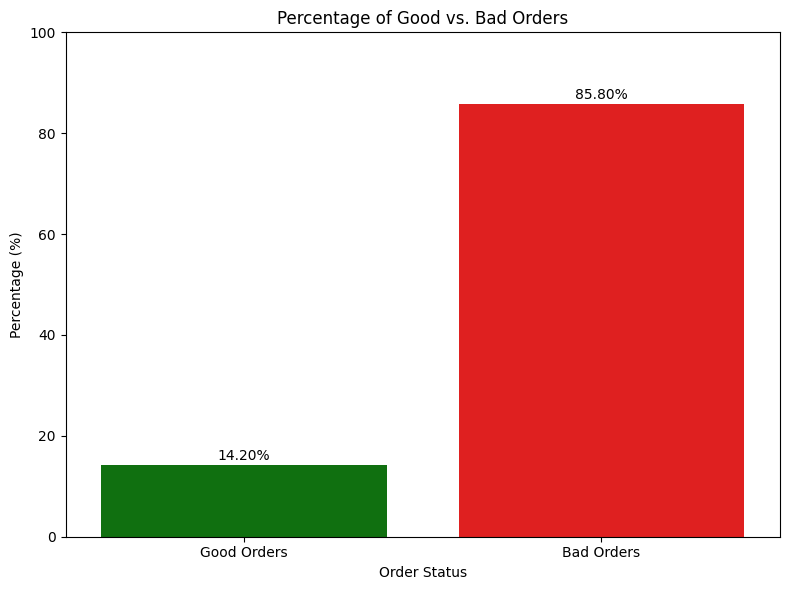

In [23]:
# Visualizing
# Create a DataFrame for plotting
order_status_data = pd.DataFrame({
    'Order Status': ['Good Orders', 'Bad Orders'],
    'Percentage': [percentage_good_orders, percentage_bad_orders]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Order Status', y='Percentage', data=order_status_data, palette={'Good Orders': 'green', 'Bad Orders': 'red'}, hue='Order Status', legend=False)
plt.title('Percentage of Good vs. Bad Orders')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100

# Add percentage labels on top of the bars
for index, row in order_status_data.iterrows():
    plt.text(index, row['Percentage'] + 1, f"{row['Percentage']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

In [24]:
df['Address'].unique()

array(['Av. de Monforte de Lemos, 12, Madrid, Spain',
       'Calle Albacete 10, Madrid, Spain',
       'Nuñez de Balboa 118, Madrid, Spain',
       'Calle Aracne, Madrid, Spain',
       'Calle de Alonso Cano 32, Madrid, Spain',
       'Calle Campezo, 20, 28022 Madrid, España',
       'Calle de Alcalá, 300, 28027 Madrid, Spain',
       'Calle de Gran Via, 100, 28027 Madrid, España',
       'Calle de Bravo Murillo, 380, Madrid, Spain',
       'Calle de la Fuente Carrantona, 50, 28030 Madrid, España',
       'Calle de Maqueda, 100, Madrid, Spain',
       'Calle de San Bernardo, 80, Madrid, Spain',
       'Calle de Sta Engracia, 100, 28003 Madrid, España',
       'Calle de Valencia, 18, 28012 Madrid, España',
       'Calle Edgar Neville, 2, 28223 Pozuelo de Alarcón, Madrid, España',
       'Calle Gran Vía, 200, Madrid, Spain',
       'Calle Salvador de Madariaga, San Sebastián de los Reyes, Spain',
       'Calle Serrano Jover, 5, 28015 Madrid, España',
       'Parque Comercial Megapark Pl

In [25]:
# Changing the word Espana to Spain, it both means same thing, this helps to understand address better

df['Address'] = df['Address'].str.replace('España', 'Spain', regex=False)

# Display unique addresses to verify the change
df['Address'].unique()

array(['Av. de Monforte de Lemos, 12, Madrid, Spain',
       'Calle Albacete 10, Madrid, Spain',
       'Nuñez de Balboa 118, Madrid, Spain',
       'Calle Aracne, Madrid, Spain',
       'Calle de Alonso Cano 32, Madrid, Spain',
       'Calle Campezo, 20, 28022 Madrid, Spain',
       'Calle de Alcalá, 300, 28027 Madrid, Spain',
       'Calle de Gran Via, 100, 28027 Madrid, Spain',
       'Calle de Bravo Murillo, 380, Madrid, Spain',
       'Calle de la Fuente Carrantona, 50, 28030 Madrid, Spain',
       'Calle de Maqueda, 100, Madrid, Spain',
       'Calle de San Bernardo, 80, Madrid, Spain',
       'Calle de Sta Engracia, 100, 28003 Madrid, Spain',
       'Calle de Valencia, 18, 28012 Madrid, Spain',
       'Calle Edgar Neville, 2, 28223 Pozuelo de Alarcón, Madrid, Spain',
       'Calle Gran Vía, 200, Madrid, Spain',
       'Calle Salvador de Madariaga, San Sebastián de los Reyes, Spain',
       'Calle Serrano Jover, 5, 28015 Madrid, Spain',
       'Parque Comercial Megapark Plaza Nor

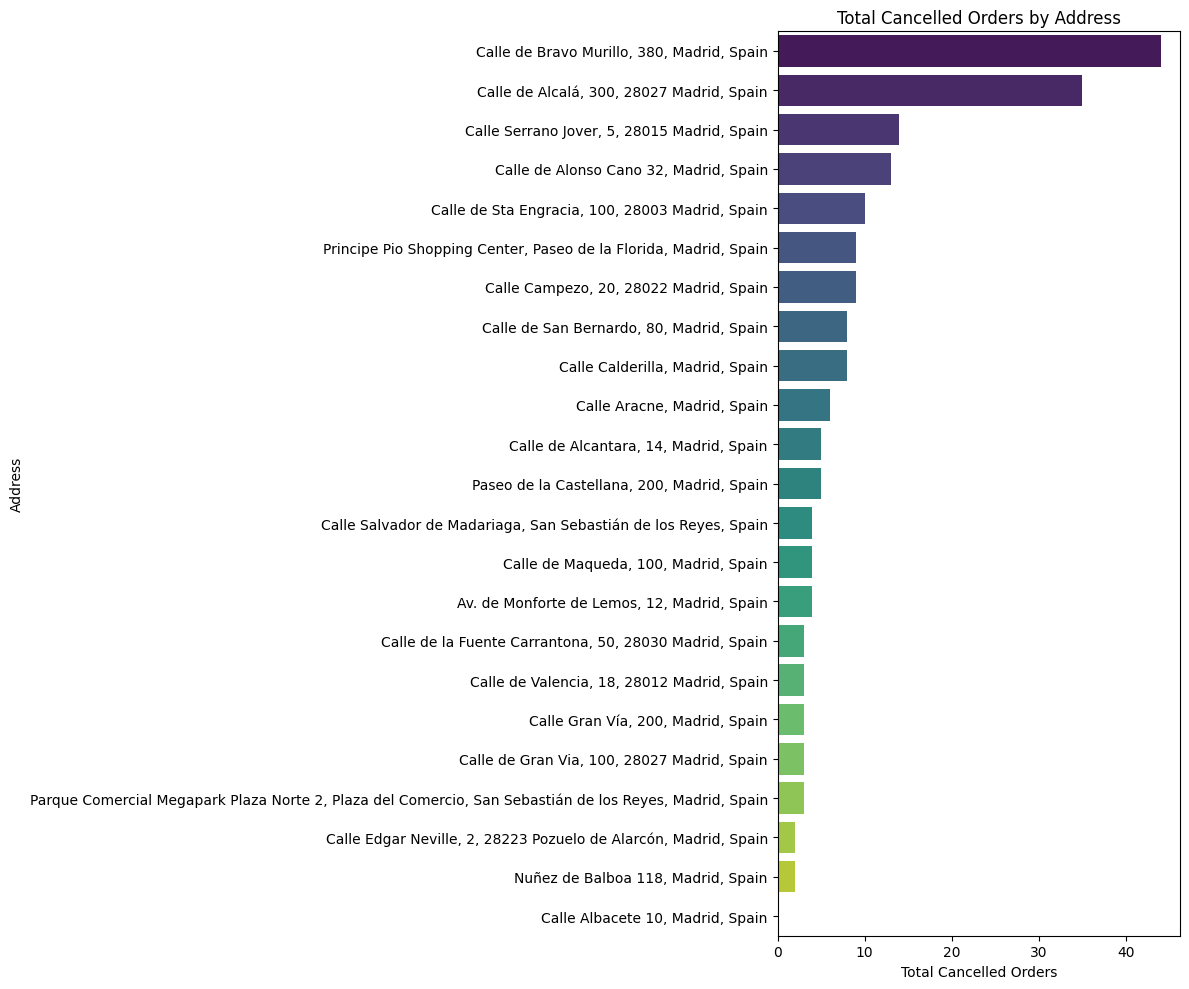

In [26]:
cancelled_orders_by_address = df.groupby('Address')['Cancelled Orders'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x=cancelled_orders_by_address.values, y=cancelled_orders_by_address.index, palette='viridis', hue=cancelled_orders_by_address.index, legend=False)
plt.xlabel('Total Cancelled Orders')
plt.ylabel('Address')
plt.title('Total Cancelled Orders by Address')
plt.tight_layout()
plt.show()

In [27]:
# Count of Reasons for cancellation
print('Common Reasons for Cancellation (Total Count across all locations):')
print(f"Customer Absent: {df['Cancelled Orders Due to Customer Absent'].sum()}")
print(f"Partner Printer/Internet Issue: {df['Cancelled Orders due to Partner Printer/internet issue'].sum()}")
print(f"Partner Products Not Available: {df['Cancelled Orders Due to Partner Products Not Available'].sum()}")
print(f"Partner Store Closed: {df['Cancelled Orders Due to Partner Store Closed'].sum()}")
print(f"Store Can't Deliver: {df['Cancelled Orders Due to Store Cant Deliver'].sum()}")

Common Reasons for Cancellation (Total Count across all locations):
Customer Absent: 47
Partner Printer/Internet Issue: 32
Partner Products Not Available: 33
Partner Store Closed: 59
Store Can't Deliver: 26


In [28]:
# Get the top 5 addresses with the highest total cancelled orders
top_5_addresses = cancelled_orders_by_address.head(5).index.tolist()

print("Top 5 addresses with the highest cancelled orders:")
for address in top_5_addresses:
    print(f"- {address}")

Top 5 addresses with the highest cancelled orders:
- Calle de Bravo Murillo, 380, Madrid, Spain
- Calle de Alcalá, 300, 28027 Madrid, Spain
- Calle Serrano Jover, 5, 28015 Madrid, Spain
- Calle de Alonso Cano 32, Madrid, Spain
- Calle de Sta Engracia, 100, 28003 Madrid, Spain


In [29]:
# Get the top 5 addresses with the highest total cancelled orders
top_5_addresses = cancelled_orders_by_address.head(5).index.tolist()

print("Top 5 addresses with the highest cancelled orders:")
for address in top_5_addresses:
    print(f"- {address}")

# Define the cancellation reason columns
cancellation_reason_columns = [
    'Cancelled Orders Due to Customer Absent',
    'Cancelled Orders due to Partner Printer/internet issue',
    'Cancelled Orders Due to Partner Products Not Available',
    'Cancelled Orders Due to Partner Store Closed',
    'Cancelled Orders Due to Store Cant Deliver'
]

# Iterate through each of the top 5 addresses
for address in top_5_addresses:
    print(f"\nAnalyzing cancellation reasons for: {address}")

    # Filter the DataFrame for the current address
    address_df = df[df['Address'] == address]

    # Calculate the sum of each cancellation reason for this address
    cancellation_sums = address_df[cancellation_reason_columns].sum()

    # Display the sums
    print("Cancellation Reasons and their Counts:")
    print(cancellation_sums.to_string())

    # Identify the most frequent cancellation reason for this address
    most_frequent_reason = cancellation_sums.idxmax()
    most_frequent_count = cancellation_sums.max()


Top 5 addresses with the highest cancelled orders:
- Calle de Bravo Murillo, 380, Madrid, Spain
- Calle de Alcalá, 300, 28027 Madrid, Spain
- Calle Serrano Jover, 5, 28015 Madrid, Spain
- Calle de Alonso Cano 32, Madrid, Spain
- Calle de Sta Engracia, 100, 28003 Madrid, Spain

Analyzing cancellation reasons for: Calle de Bravo Murillo, 380, Madrid, Spain
Cancellation Reasons and their Counts:
Cancelled Orders Due to Customer Absent                    1
Cancelled Orders due to Partner Printer/internet issue     1
Cancelled Orders Due to Partner Products Not Available    29
Cancelled Orders Due to Partner Store Closed               6
Cancelled Orders Due to Store Cant Deliver                 7

Analyzing cancellation reasons for: Calle de Alcalá, 300, 28027 Madrid, Spain
Cancellation Reasons and their Counts:
Cancelled Orders Due to Customer Absent                    6
Cancelled Orders due to Partner Printer/internet issue    24
Cancelled Orders Due to Partner Products Not Available     

In [30]:
# Filter the DataFrame for the top 5 addresses
top_5_df = df[df['Address'].isin(top_5_addresses)].copy()

# Define the cancellation reason columns (ensure these are correctly identified from your df.info() or head() output)
cancellation_reason_columns = [
    'Cancelled Orders Due to Customer Absent',
    'Cancelled Orders due to Partner Printer/internet issue',
    'Cancelled Orders Due to Partner Products Not Available',
    'Cancelled Orders Due to Partner Store Closed',
    'Cancelled Orders Due to Store Cant Deliver'
]

# Melt the DataFrame to transform cancellation reasons into a long format for plotting
melted_cancellations = top_5_df.melt(id_vars=['Address'],
                                      value_vars=cancellation_reason_columns,
                                      var_name='Cancellation Reason',
                                      value_name='Count')

# Group by Address and Cancellation Reason, then sum the counts


Identify Top 5 Locations and Reasons
Subtask:
Get the top 5 addresses with the highest total cancelled orders. For each of these addresses, calculate the sum of each specific cancellation reason and identify the most common reason.


In [31]:
reason_counts_by_address = melted_cancellations.groupby(['Address', 'Cancellation Reason'])['Count'].sum().reset_index()


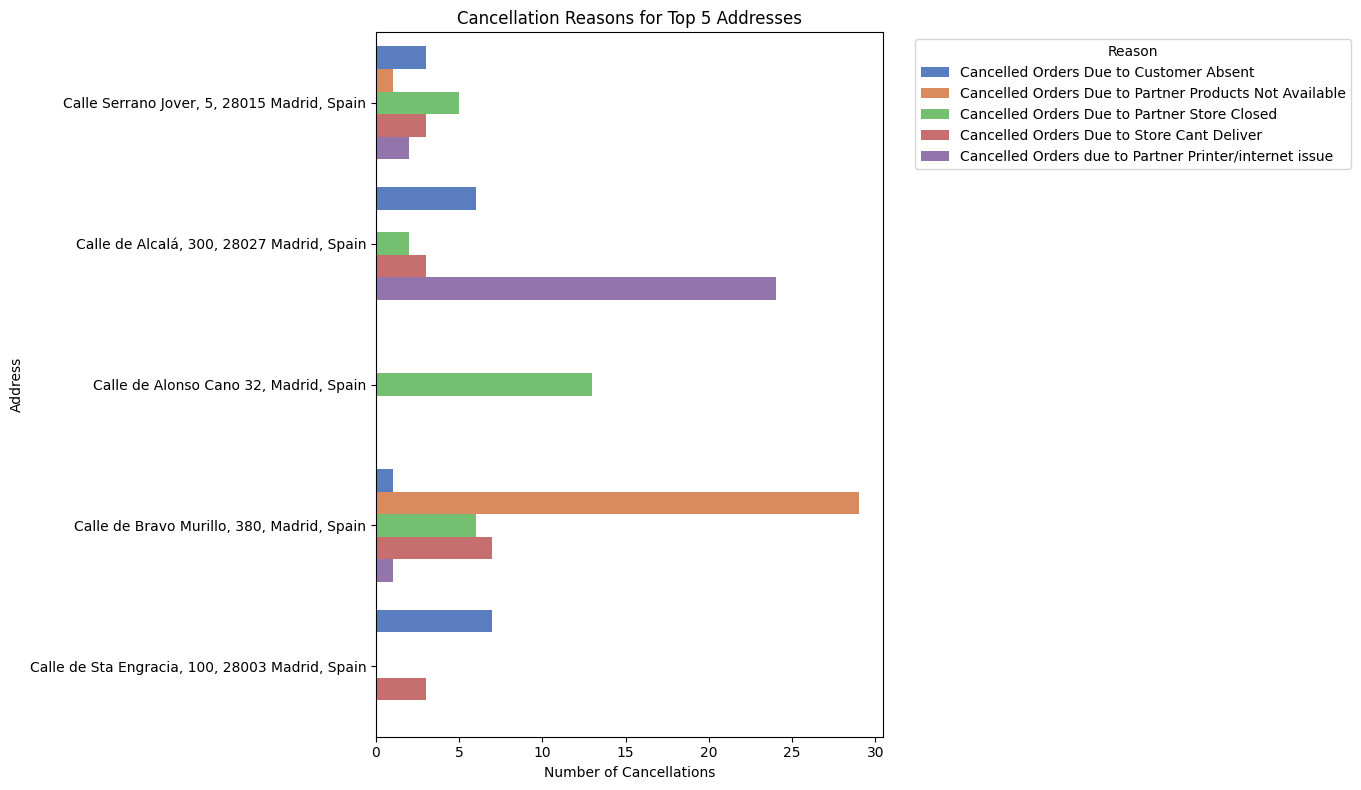

In [32]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y='Address', hue='Cancellation Reason', data=reason_counts_by_address, palette='muted')
plt.title('Cancellation Reasons for Top 5 Addresses')
plt.xlabel('Number of Cancellations')
plt.ylabel('Address')
plt.legend(title='Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

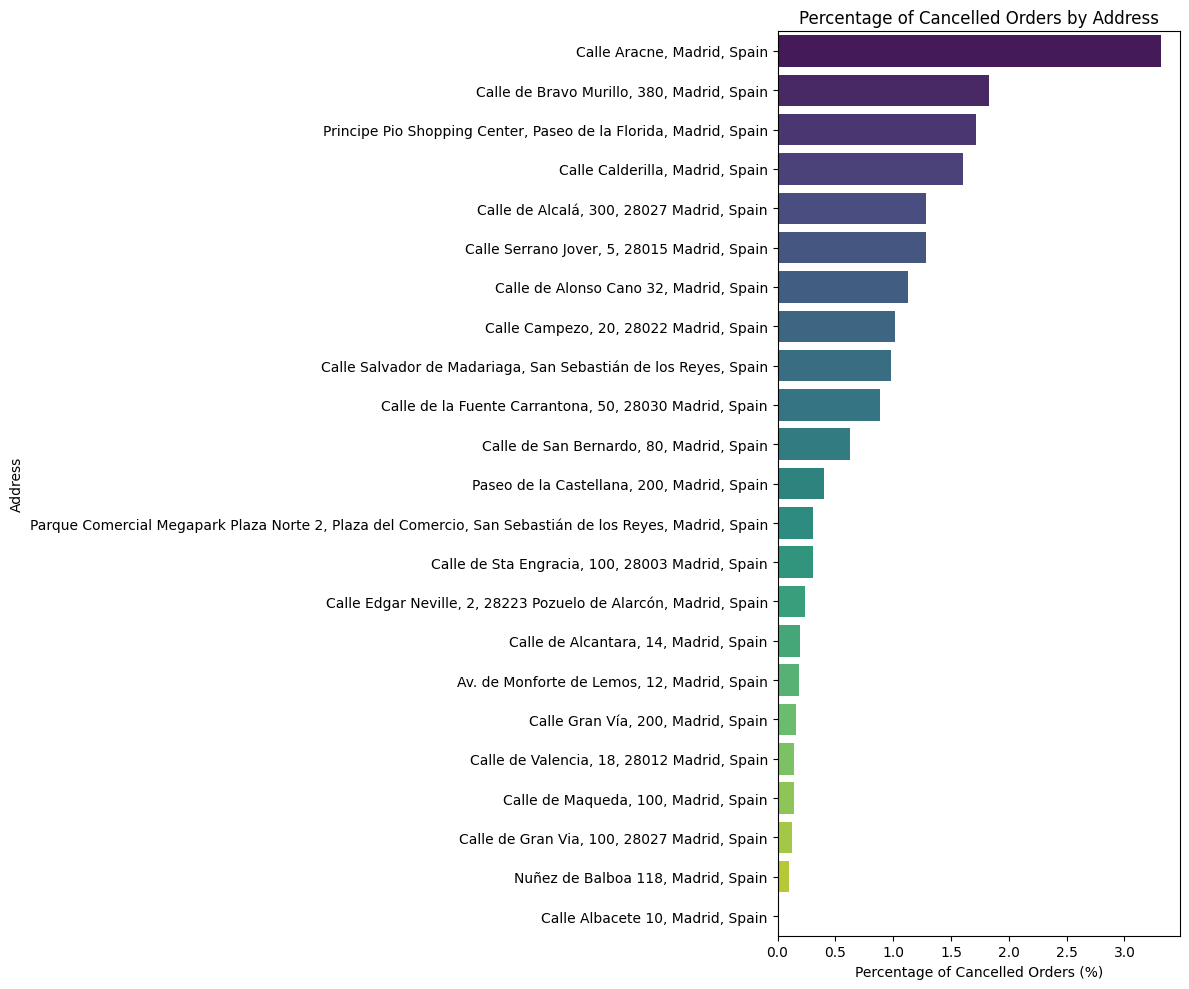

In [33]:
# Calculate total cancelled orders per address
total_cancelled_per_address = df.groupby('Address')['Cancelled Orders'].sum()

# Calculate total orders (delivered + cancelled) per address
# We'll consider 'Number of delivered orders' + 'Cancelled Orders' as total orders for a given row's context
# and then sum these up per address to get a robust total order count.
df['Total_Orders_Per_Row'] = df['Number of delivered orders'] + df['Cancelled Orders']
total_orders_per_address = df.groupby('Address')['Total_Orders_Per_Row'].sum()

# Calculate the percentage of cancelled orders for each address
# Handle cases where total_orders_per_address might be zero to avoid division by zero
percentage_cancelled_by_address = ((total_cancelled_per_address / total_orders_per_address) * 100).fillna(0)

# Sort the values for better visualization
percentage_cancelled_by_address = percentage_cancelled_by_address.sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x=percentage_cancelled_by_address.values, y=percentage_cancelled_by_address.index, palette='viridis', hue=percentage_cancelled_by_address.index, legend=False)
plt.xlabel('Percentage of Cancelled Orders (%)')
plt.ylabel('Address')
plt.title('Percentage of Cancelled Orders by Address')
plt.tight_layout()
plt.show()

In [34]:
# Individual Relationship of Refunds to Customer with Bad Rated Reasons
# Assuming your dataframe is called 'df'
columns_to_check = ['Refunds to customer', 'Bad rated orders due to wrong or Missing Products',
                    'Bad rated orders due to store packaging Issues',
                    'Bad rated orders due to store allergy not considered',
                    'Bad rated orders due to to  Poor Quality']

correlation_matrix = df[columns_to_check].corr()
print(correlation_matrix['Refunds to customer']) # Shows the individual relationship with each

Refunds to customer                                     1.000000
Bad rated orders due to wrong or Missing Products       0.805926
Bad rated orders due to store packaging Issues          0.033459
Bad rated orders due to store allergy not considered    0.019301
Bad rated orders due to to  Poor Quality                0.142165
Name: Refunds to customer, dtype: float64


In [35]:
# Individual Relationship of Basket size with Bad Rated Reasons
# Assuming your dataframe is called 'df'
columns_to_check = ['Basket size', 'Bad rated orders due to wrong or Missing Products',
                    'Bad rated orders due to store packaging Issues',
                    'Bad rated orders due to store allergy not considered',
                    'Bad rated orders due to to  Poor Quality']

correlation_matrix = df[columns_to_check].corr()
print(correlation_matrix['Basket size']) # Shows the individual relationship with each

Basket size                                             1.000000
Bad rated orders due to wrong or Missing Products      -0.116182
Bad rated orders due to store packaging Issues         -0.034217
Bad rated orders due to store allergy not considered   -0.077241
Bad rated orders due to to  Poor Quality               -0.089411
Name: Basket size, dtype: float64


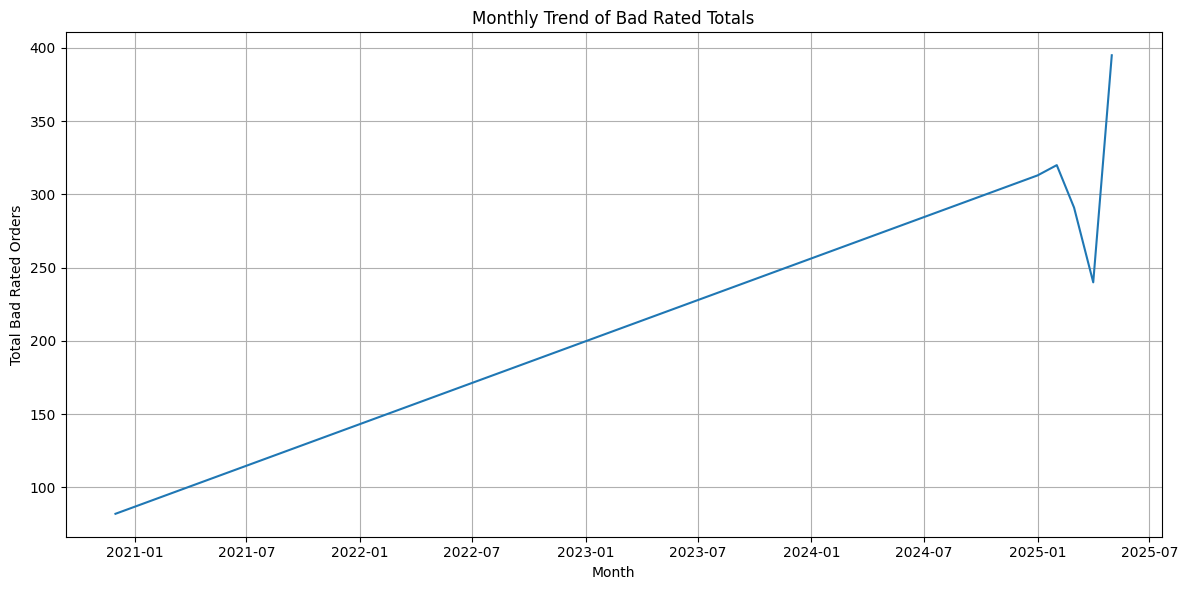

In [36]:
# MONTHLY TREND OF BAD RATED TOTALS
# Convert 'Week' column to datetime objects
df['Week'] = pd.to_datetime(df['Week'])

# Extract month and year to group by month
df['Month'] = df['Week'].dt.to_period('M')

# Group by month and sum 'Bad Rated Total'
monthly_bad_rated_trend = df.groupby('Month')['Bad Rated Total'].sum().reset_index()

# Convert 'Month' back to datetime for plotting
monthly_bad_rated_trend['Month'] = monthly_bad_rated_trend['Month'].dt.to_timestamp()

# Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Bad Rated Total', data=monthly_bad_rated_trend)
plt.title('Monthly Trend of Bad Rated Totals')
plt.xlabel('Month')
plt.ylabel('Total Bad Rated Orders')
plt.grid(True)
plt.tight_layout()
plt.show()

### Time Series Prediction

Subtask:
Convert 'Week' to datetime, create numerical time features (e.g., year, month, week of year), and ensure all relevant columns are numeric.

In [37]:
df['Week'] = pd.to_datetime(df['Week'])
df['Year'] = df['Week'].dt.year
df['Month'] = df['Week'].dt.month
df['Week_of_Year'] = df['Week'].dt.isocalendar().week.astype(int)

print("DataFrame with new time features:")
display(df[['Week', 'Year', 'Month', 'Week_of_Year']].head())

DataFrame with new time features:


,Week,Year,Month,Week_of_Year
0,2025-01-04,2025,1,1
1,2025-02-01,2025,2,5
2,2025-02-08,2025,2,6
3,2025-02-15,2025,2,7
4,2025-03-08,2025,3,10



### Create lagged features for 'Refunds to customer' and potentially other relevant metrics (e.g., 'Bad Rated Total') to capture temporal dependencies.

This ensures that lagged features are created correctly, the DataFrame must first be sorted by the 'Week' column in chronological order. This is a crucial first step before applying the shift() method.

In [38]:
df = df.sort_values(by='Week')
print("DataFrame sorted by 'Week' column:")
display(df.head())

DataFrame sorted by 'Week' column:


,Week,Address,Number of delivered orders,Basket size,Bad rated orders due to wrong or Missing Products,Bad rated orders due to store packaging Issues,Bad rated orders due to store allergy not considered,Bad rated orders due to to Poor Quality,Cancelled Orders Due to Customer Absent,Cancelled Orders due to Partner Printer/internet issue,Cancelled Orders Due to Partner Products Not Available,Cancelled Orders Due to Partner Store Closed,Cancelled Orders Due to Store Cant Deliver,Refunds to customer,Cancelled Orders,Bad Rated Total,Total_Orders_Per_Row,Month,Year,Week_of_Year
100,2020-12-28,"Calle de Alonso Cano 32, Madrid, Spain",41,19.62,2,0,0,0,0,0,0,0,0,5.89,0,2,41,12,2020,53
371,2020-12-28,"Calle Serrano Jover, 5, 28015 Madrid, Spain",22,19.37,2,0,0,0,0,0,0,1,0,11.62,1,2,23,12,2020,53
330,2020-12-28,"Calle Gran Vía, 200, Madrid, Spain",110,19.82,3,1,0,0,1,0,0,0,0,29.73,1,4,111,12,2020,53
299,2020-12-28,"Calle Edgar Neville, 2, 28223 Pozuelo de Alarc...",40,26.82,0,0,0,0,1,0,0,0,0,0.00,1,0,41,12,2020,53
51,2020-12-28,"Nuñez de Balboa 118, Madrid, Spain",51,20.20,3,0,0,0,0,0,0,0,0,9.09,0,3,51,12,2020,53


In [39]:
for i in range(1, 5):
    df[f'Refunds_Lag_{i}'] = df.groupby('Address')['Refunds to customer'].shift(i)
    df[f'BadRated_Lag_{i}'] = df.groupby('Address')['Bad Rated Total'].shift(i)

# Drop rows with NaN values introduced by lagging (usually the first few rows for each address)
df.dropna(inplace=True)

print("DataFrame with new lagged features:")

DataFrame with new lagged features:


In [40]:
# Define features (X) and target (y)
X_columns = [
    'Number of delivered orders',
    'Basket size',
    'Cancelled Orders',
    'Bad Rated Total',
    'Year',
    'Month',
    'Week_of_Year',
    'Refunds_Lag_1',
    'BadRated_Lag_1',
    'Refunds_Lag_2',
    'BadRated_Lag_2',
    'Refunds_Lag_3',
    'BadRated_Lag_3',
    'Refunds_Lag_4',
    'BadRated_Lag_4',
    'Address' # Added Address to X_columns
]
y_column = 'Refunds to customer'

# Ensure all X_columns exist in df
X_columns = [col for col in X_columns if col in df.columns]

X = df[X_columns]
y = df[y_column]

# Handle categorical 'Address' feature using one-hot encoding
X = pd.get_dummies(X, columns=['Address'], drop_first=True)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of X:")
display(X.head())
print("First 5 rows of y:")
display(y.head())

Features (X) shape: (408, 37)
Target (y) shape: (408,)
First 5 rows of X:


,Number of delivered orders,Basket size,Cancelled Orders,Bad Rated Total,Year,Month,Week_of_Year,Refunds_Lag_1,BadRated_Lag_1,Refunds_Lag_2,...,"Address_Calle de Gran Via, 100, 28027 Madrid, Spain","Address_Calle de Maqueda, 100, Madrid, Spain","Address_Calle de San Bernardo, 80, Madrid, Spain","Address_Calle de Sta Engracia, 100, 28003 Madrid, Spain","Address_Calle de Valencia, 18, 28012 Madrid, Spain","Address_Calle de la Fuente Carrantona, 50, 28030 Madrid, Spain","Address_Nuñez de Balboa 118, Madrid, Spain","Address_Parque Comercial Megapark Plaza Norte 2, Plaza del Comercio, San Sebastián de los Reyes, Madrid, Spain","Address_Paseo de la Castellana, 200, Madrid, Spain","Address_Principe Pio Shopping Center, Paseo de la Florida, Madrid, Spain"
332,119,17.97,1,3,2025,1,4,66.96,11.0,17.79,...,False,False,False,False,False,False,False,False,False,False
355,22,18.15,0,1,2025,1,4,0.00,0.0,0.00,...,False,False,False,False,False,False,False,False,False,False
384,77,16.26,0,8,2025,1,4,19.78,5.0,0.00,...,False,False,False,False,False,False,False,False,False,False
310,38,20.34,0,2,2025,1,4,6.00,1.0,0.00,...,False,False,False,False,False,False,False,False,False,False
464,31,17.64,0,0,2025,1,4,0.00,0.0,16.50,...,False,False,False,False,False,False,False,False,False,True


First 5 rows of y:


,Refunds to customer
332,26.96
355,0.00
384,24.39
310,12.20
464,0.00


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split data into training and testing sets
# For time series, a simple train/test split might not be ideal, but for a general regression approach, it works.
# A more robust time series validation would be time-based splitting.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 7.92
Mean Squared Error (MSE): 176.55
Root Mean Squared Error (RMSE): 13.29


In [42]:
print(df.columns)

Index(['Week', 'Address', 'Number of delivered orders', 'Basket size',
       'Bad rated orders due to wrong or Missing Products',
       'Bad rated orders due to store packaging Issues',
       'Bad rated orders due to store allergy not considered',
       'Bad rated orders due to to  Poor Quality',
       'Cancelled Orders Due to Customer Absent',
       'Cancelled Orders due to Partner Printer/internet issue',
       'Cancelled Orders Due to Partner Products Not Available',
       'Cancelled Orders Due to Partner Store Closed',
       'Cancelled Orders Due to Store Cant Deliver', 'Refunds to customer',
       'Cancelled Orders', 'Bad Rated Total', 'Total_Orders_Per_Row', 'Month',
       'Year', 'Week_of_Year', 'Refunds_Lag_1', 'BadRated_Lag_1',
       'Refunds_Lag_2', 'BadRated_Lag_2', 'Refunds_Lag_3', 'BadRated_Lag_3',
       'Refunds_Lag_4', 'BadRated_Lag_4'],
      dtype='object')


In [43]:
import pandas as pd
import numpy as np

# Assuming df, model, X_train are available from previous cells

# 1. Get the last date in the DataFrame
last_date = df['Week'].max()

# 2. Get unique addresses
unique_addresses = df['Address'].unique()

# 3. Generate future dates for the next 5 weeks
# Assuming weekly data, and the 'Week' column represents the end of the week.
# Let's add 7 days to the last_date and then generate 5 subsequent weeks.
future_weeks = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=5, freq='W-SAT')

# Prepare a list to store future predictions
all_future_predictions = []

# Get the list of all Address dummy columns from X_train
address_dummy_columns = [col for col in X_train.columns if col.startswith('Address_')]
# Get the non-dummy feature columns that are not lags and not 'Address'
non_lag_input_features = [
    'Number of delivered orders',
    'Basket size',
    'Cancelled Orders',
    'Bad Rated Total'
]
time_features = ['Year', 'Month', 'Week_of_Year']

# 4. Iterate through each unique address for iterative prediction
for address in unique_addresses:
    # a. Get last known state for current address
    # Sort by 'Week' to ensure we get the absolute last entry
    last_row_for_address = df[df['Address'] == address].sort_values(by='Week').iloc[-1]

    # Initialize current lagged features. current_refunds_lags[0] will be the Refund from the last historical week.
    current_refunds_lags = [last_row_for_address['Refunds to customer']] + [last_row_for_address[f'Refunds_Lag_{i}'] for i in range(1, 4)]
    current_bad_rated_lags = [last_row_for_address['Bad Rated Total']] + [last_row_for_address[f'BadRated_Lag_{i}'] for i in range(1, 4)]

    # b. Calculate average non-lagged features for current address to use as proxies for future inputs
    avg_feature_values = df[df['Address'] == address][non_lag_input_features].mean().to_dict()

    # Store predictions for this address and iterate to propagate lags
    address_predictions = []

    for i, future_week in enumerate(future_weeks):
        # i. Construct X_pred for the current future week
        features_for_pred = {}
        features_for_pred['Number of delivered orders'] = avg_feature_values['Number of delivered orders']
        features_for_pred['Basket size'] = avg_feature_values['Basket size']
        features_for_pred['Cancelled Orders'] = avg_feature_values['Cancelled Orders']
        features_for_pred['Bad Rated Total'] = avg_feature_values['Bad Rated Total'] # Using average as input

        features_for_pred['Year'] = future_week.year
        features_for_pred['Month'] = future_week.month
        features_for_pred['Week_of_Year'] = future_week.isocalendar().week

        # Propagate lagged features using current_lags (which are updated iteratively)
        features_for_pred['Refunds_Lag_1'] = current_refunds_lags[0]
        features_for_pred['BadRated_Lag_1'] = current_bad_rated_lags[0]
        features_for_pred['Refunds_Lag_2'] = current_refunds_lags[1]
        features_for_pred['BadRated_Lag_2'] = current_bad_rated_lags[1]
        features_for_pred['Refunds_Lag_3'] = current_refunds_lags[2]
        features_for_pred['BadRated_Lag_3'] = current_bad_rated_lags[2]
        features_for_pred['Refunds_Lag_4'] = current_refunds_lags[3]
        features_for_pred['BadRated_Lag_4'] = current_bad_rated_lags[3]

        # Convert to DataFrame for one-hot encoding
        X_pred_single_row = pd.DataFrame([features_for_pred])

        # Add the 'Address' column for one-hot encoding
        X_pred_single_row['Address'] = address

        # ii. One-Hot Encode X_pred and align columns
        X_pred_encoded = pd.get_dummies(X_pred_single_row, columns=['Address'], drop_first=True)

        # Reindex to ensure all columns from X_train are present, filling missing with 0
        # This is crucial for the model to receive the exact same column structure as during training
        X_pred_aligned = X_pred_encoded.reindex(columns=X_train.columns, fill_value=0)

        # iii. Predict
        predicted_refund = model.predict(X_pred_aligned)[0]

        # Ensure predictions are not negative (refunds cannot be negative)
        predicted_refund = max(0, predicted_refund)

        # iv. Store prediction
        all_future_predictions.append({
            'Week': future_week,
            'Address': address,
            'Predicted Refunds': predicted_refund
        })

        # v. Update lagged features for next iteration
        # The current predicted refund becomes Refund_Lag_1 for the next week
        current_refunds_lags = [predicted_refund] + current_refunds_lags[:-1]
        # The current average 'Bad Rated Total' (used as input) becomes BadRated_Lag_1 for the next week
        current_bad_rated_lags = [avg_feature_values['Bad Rated Total']] + current_bad_rated_lags[:-1]


# Create final DataFrame of future predictions
forecast_df = pd.DataFrame(all_future_predictions)

print("Future Refunds Forecast for the next 5 weeks per address:")
display(forecast_df)

Future Refunds Forecast for the next 5 weeks per address:


,Week,Address,Predicted Refunds
0,2025-06-07,"Calle Gran Vía, 200, Madrid, Spain",19.1595
1,2025-06-14,"Calle Gran Vía, 200, Madrid, Spain",15.3727
2,2025-06-21,"Calle Gran Vía, 200, Madrid, Spain",14.7265
3,2025-06-28,"Calle Gran Vía, 200, Madrid, Spain",13.1091
4,2025-07-05,"Calle Gran Vía, 200, Madrid, Spain",14.1890
...,...,...,...
110,2025-06-07,"Calle de la Fuente Carrantona, 50, 28030 Madri...",0.0000
111,2025-06-14,"Calle de la Fuente Carrantona, 50, 28030 Madri...",0.0000
112,2025-06-21,"Calle de la Fuente Carrantona, 50, 28030 Madri...",0.0000
113,2025-06-28,"Calle de la Fuente Carrantona, 50, 28030 Madri...",0.0000


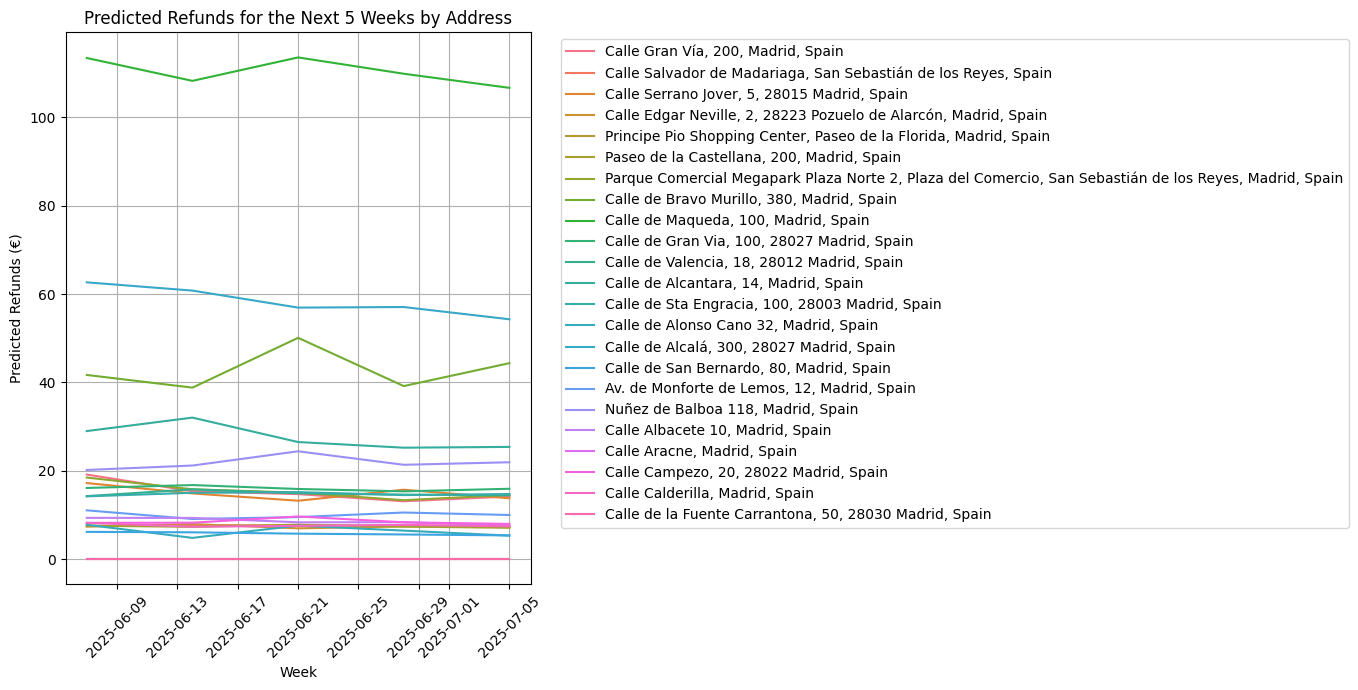

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Week', y='Predicted Refunds', hue='Address', data=forecast_df)
plt.title('Predicted Refunds for the Next 5 Weeks by Address')
plt.xlabel('Week')
plt.ylabel('Predicted Refunds (€)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()